In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
data = pd.read_csv("../../HR-Employee-Attrition.csv")

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
print("Column names:")
display(data.columns.tolist())

print("\nData types:")
display(data.dtypes)

print("\nMissing values:")
display(data.isnull().sum())

print("\nAttrition counts:")
display(data["Attrition"].value_counts())

attrition_rate = (
    data["Attrition"]
    .eq("Yes")
    .mean()
    * 100
)

print(f"\nOverall attrition rate: {attrition_rate:.1f}%")

Column names:


['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']


Data types:


Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL


Missing values:


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince


Attrition counts:


Attrition
No     1233
Yes     237
Name: count, dtype: int64


Overall attrition rate: 16.1%


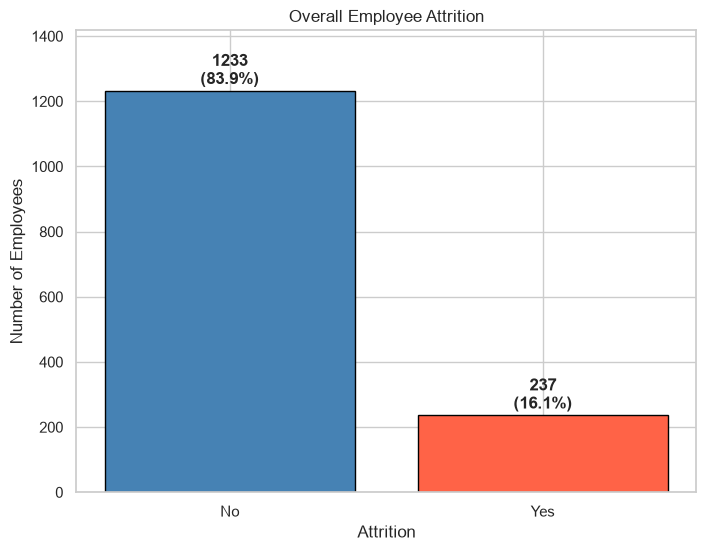

In [4]:
attrition_counts = (
    data["Attrition"]
    .value_counts()
    .reindex(["No", "Yes"])
)

attrition_percentages = (
    attrition_counts / attrition_counts.sum() * 100
)

plt.figure(figsize=(8, 6))

bars = plt.bar(
    attrition_counts.index,
    attrition_counts.values,
    color=["steelblue", "tomato"],
    edgecolor="black"
)

plt.title("Overall Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

# Add counts and percentages above the bars
for bar, count, percentage in zip(
    bars,
    attrition_counts.values,
    attrition_percentages.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, attrition_counts.max() * 1.15)
plt.show()

In [6]:
department_attrition = (
    data.assign(Left=data["Attrition"].eq("Yes"))
    .groupby("Department")
    .agg(
        Total_Employees=("Attrition", "size"),
        Employees_Left=("Left", "sum"),
        Attrition_Rate=("Left", "mean")
    )
    .reset_index()
)

department_attrition["Attrition_Rate"] *= 100

department_attrition = department_attrition.sort_values(
    "Attrition_Rate",
    ascending=False
)

display(department_attrition)

,Department,Total_Employees,Employees_Left,Attrition_Rate
2,Sales,446,92,20.627803
0,Human Resources,63,12,19.047619
1,Research & Development,961,133,13.839750


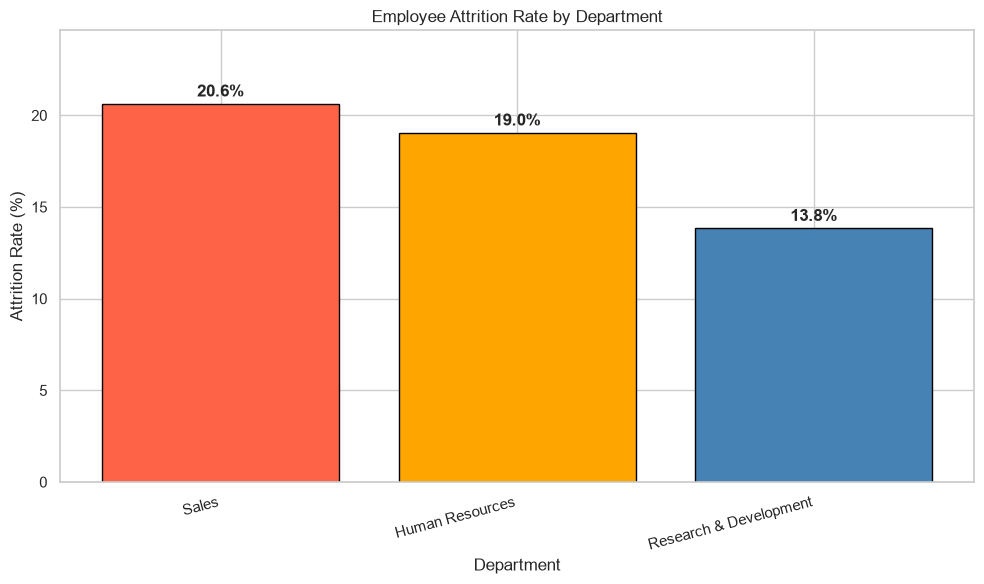

In [7]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    department_attrition["Department"],
    department_attrition["Attrition_Rate"],
    color=["tomato", "orange", "steelblue"],
    edgecolor="black"
)

plt.title("Employee Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15, ha="right")

for bar, rate in zip(
    bars,
    department_attrition["Attrition_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{rate:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, department_attrition["Attrition_Rate"].max() + 4)
plt.tight_layout()
plt.show()

In [8]:
overtime_attrition = (
    data.assign(Left=data["Attrition"].eq("Yes"))
    .groupby("OverTime")
    .agg(
        Total_Employees=("Attrition", "size"),
        Employees_Left=("Left", "sum"),
        Attrition_Rate=("Left", "mean")
    )
    .reset_index()
)

overtime_attrition["Attrition_Rate"] *= 100

display(overtime_attrition)

,OverTime,Total_Employees,Employees_Left,Attrition_Rate
0,No,1054,110,10.436433
1,Yes,416,127,30.528846


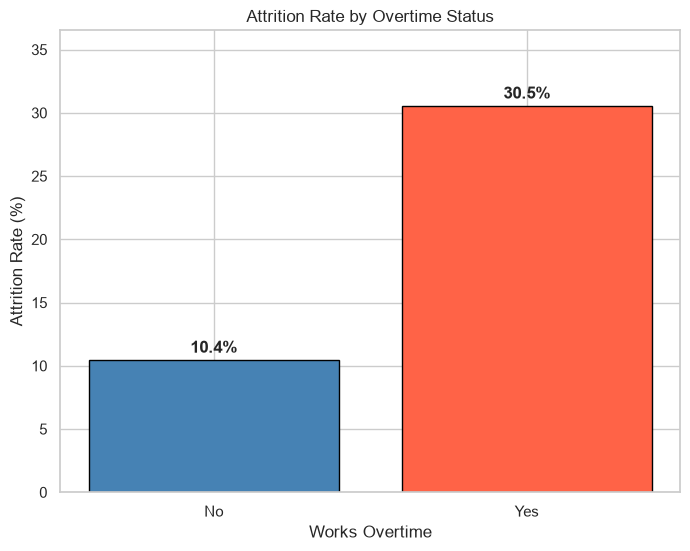

In [9]:
plt.figure(figsize=(8, 6))

bars = plt.bar(
    overtime_attrition["OverTime"],
    overtime_attrition["Attrition_Rate"],
    color=["steelblue", "tomato"],
    edgecolor="black"
)

plt.title("Attrition Rate by Overtime Status")
plt.xlabel("Works Overtime")
plt.ylabel("Attrition Rate (%)")

for bar, rate in zip(
    bars,
    overtime_attrition["Attrition_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{rate:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, overtime_attrition["Attrition_Rate"].max() + 6)
plt.show()

In [10]:
age_summary = (
    data.groupby("Attrition")["Age"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(1)
)

display(age_summary)

,count,mean,median,min,max
Attrition,,,,,
No,1233,37.6,36.0,18,60
Yes,237,33.6,32.0,18,58


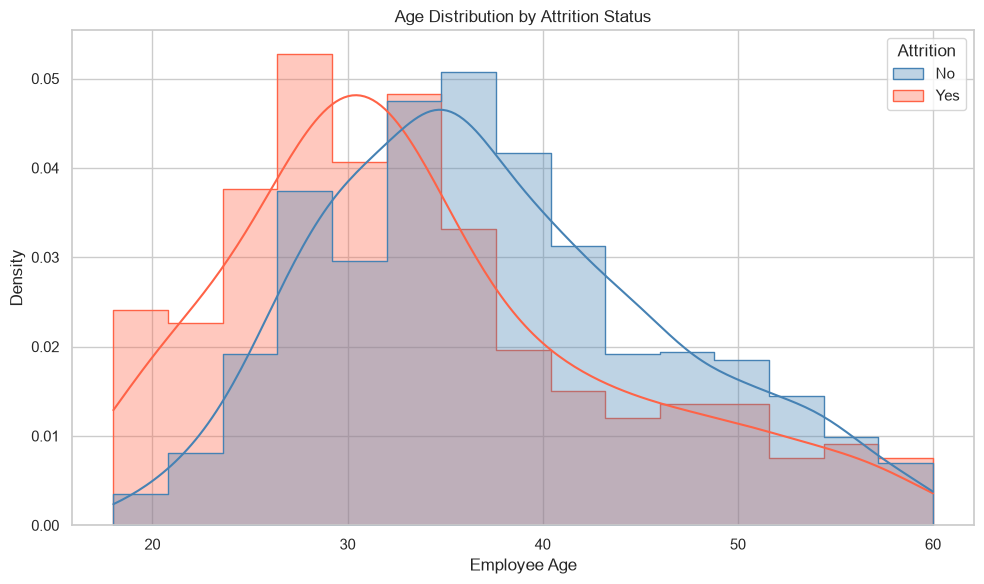

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="Age",
    hue="Attrition",
    hue_order=["No", "Yes"],
    bins=15,
    stat="density",
    common_norm=False,
    kde=True,
    element="step",
    palette={"No": "steelblue", "Yes": "tomato"},
    alpha=0.35
)

plt.title("Age Distribution by Attrition Status")
plt.xlabel("Employee Age")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

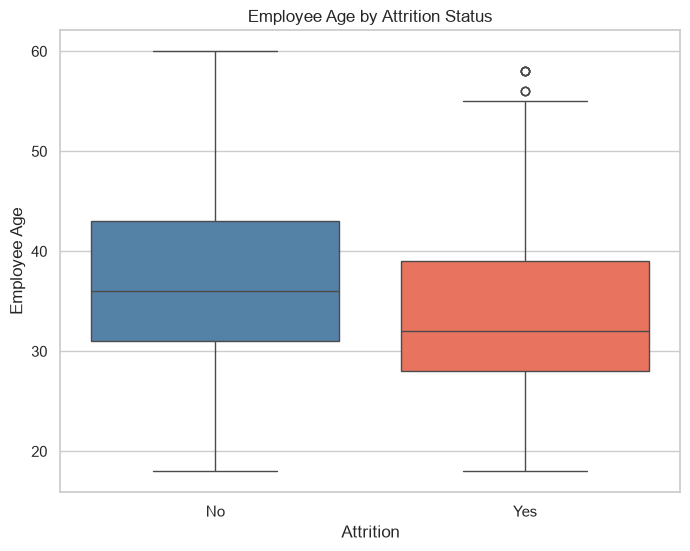

In [12]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="Attrition",
    y="Age",
    order=["No", "Yes"],
    hue="Attrition",
    palette={"No": "steelblue", "Yes": "tomato"},
    legend=False
)

plt.title("Employee Age by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Employee Age")
plt.show()

In [13]:
income_summary = (
    data.groupby("Attrition")["MonthlyIncome"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(income_summary)

,count,mean,median,min,max
Attrition,,,,,
No,1233,6832.74,5204.0,1051,19999
Yes,237,4787.09,3202.0,1009,19859


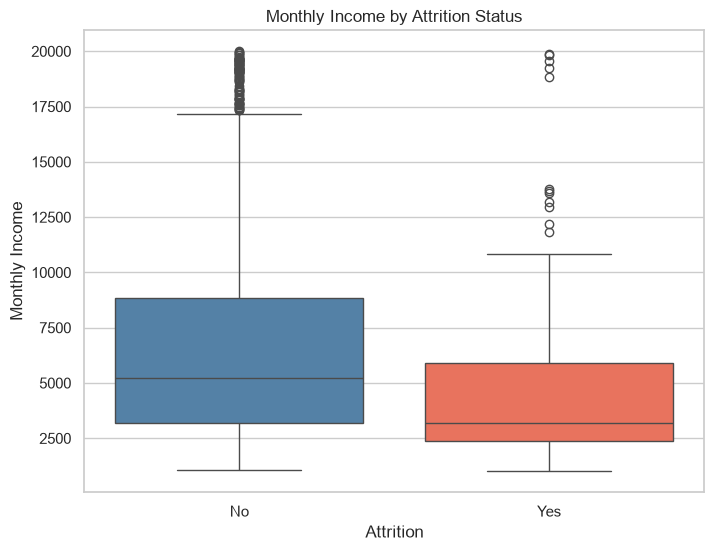

In [14]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="Attrition",
    y="MonthlyIncome",
    order=["No", "Yes"],
    hue="Attrition",
    palette={"No": "steelblue", "Yes": "tomato"},
    legend=False
)

plt.title("Monthly Income by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

In [15]:
income_summary = (
    data.groupby("Attrition")["MonthlyIncome"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(income_summary)

,count,mean,median,min,max
Attrition,,,,,
No,1233,6832.74,5204.0,1051,19999
Yes,237,4787.09,3202.0,1009,19859


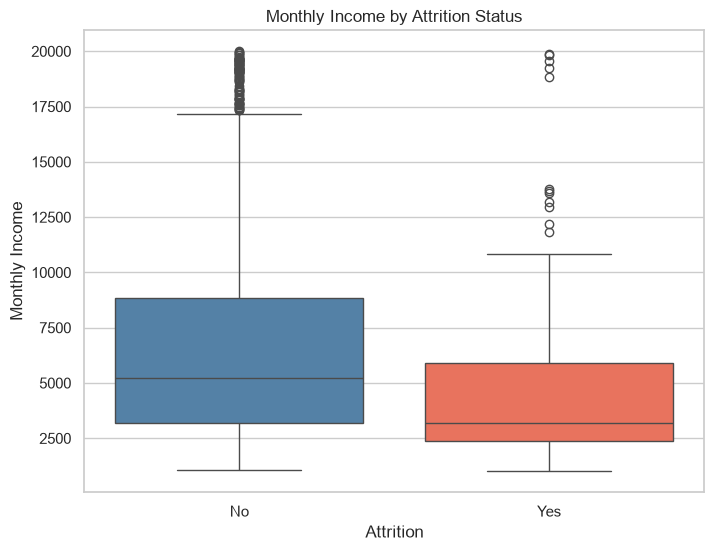

In [16]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="Attrition",
    y="MonthlyIncome",
    order=["No", "Yes"],
    hue="Attrition",
    palette={"No": "steelblue", "Yes": "tomato"},
    legend=False
)

plt.title("Monthly Income by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

In [17]:
job_satisfaction = (
    data.assign(Left=data["Attrition"].eq("Yes"))
    .groupby("JobSatisfaction")
    .agg(
        Total_Employees=("Left", "size"),
        Employees_Left=("Left", "sum"),
        Attrition_Rate=("Left", "mean")
    )
    .reset_index()
)

job_satisfaction["Attrition_Rate"] *= 100

work_life_balance = (
    data.assign(Left=data["Attrition"].eq("Yes"))
    .groupby("WorkLifeBalance")
    .agg(
        Total_Employees=("Left", "size"),
        Employees_Left=("Left", "sum"),
        Attrition_Rate=("Left", "mean")
    )
    .reset_index()
)

work_life_balance["Attrition_Rate"] *= 100

print("Job satisfaction:")
display(job_satisfaction)

print("Work-life balance:")
display(work_life_balance)

Job satisfaction:


,JobSatisfaction,Total_Employees,Employees_Left,Attrition_Rate
0,1,289,66,22.837370
1,2,280,46,16.428571
2,3,442,73,16.515837
3,4,459,52,11.328976


Work-life balance:


,WorkLifeBalance,Total_Employees,Employees_Left,Attrition_Rate
0,1,80,25,31.250000
1,2,344,58,16.860465
2,3,893,127,14.221725
3,4,153,27,17.647059


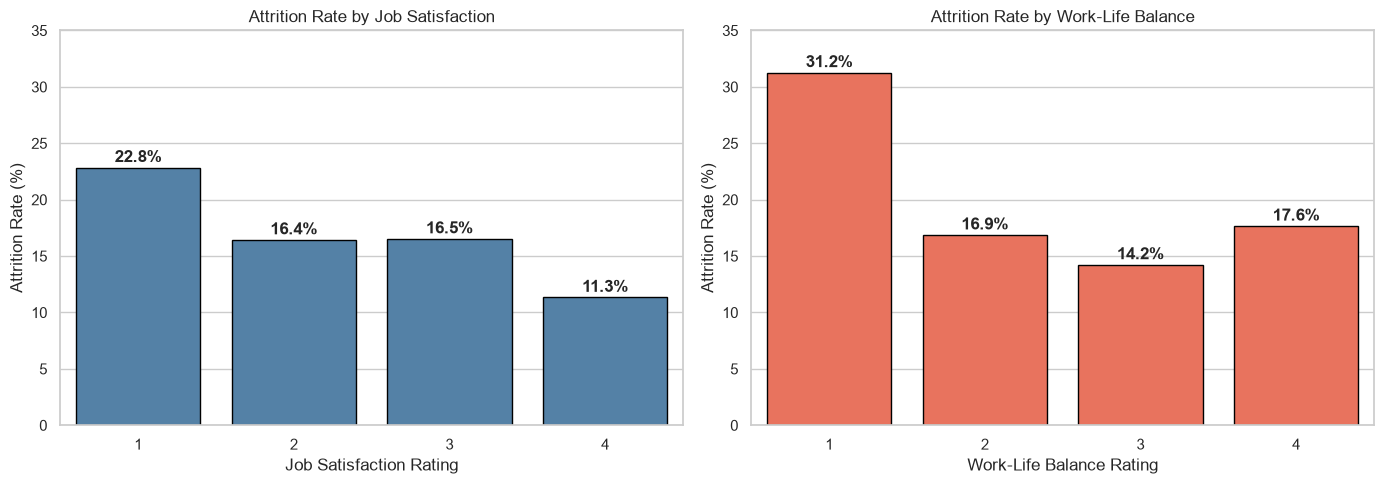

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Job satisfaction chart
sns.barplot(
    data=job_satisfaction,
    x="JobSatisfaction",
    y="Attrition_Rate",
    color="steelblue",
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("Attrition Rate by Job Satisfaction")
axes[0].set_xlabel("Job Satisfaction Rating")
axes[0].set_ylabel("Attrition Rate (%)")

# Work-life balance chart
sns.barplot(
    data=work_life_balance,
    x="WorkLifeBalance",
    y="Attrition_Rate",
    color="tomato",
    edgecolor="black",
    ax=axes[1]
)

axes[1].set_title("Attrition Rate by Work-Life Balance")
axes[1].set_xlabel("Work-Life Balance Rating")
axes[1].set_ylabel("Attrition Rate (%)")

# Add percentage labels
for axis in axes:
    for bar in axis.patches:
        height = bar.get_height()
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.5,
            f"{height:.1f}%",
            ha="center",
            fontweight="bold"
        )

    axis.set_ylim(0, 35)

plt.tight_layout()
plt.show()

In [19]:
correlation_data = data.copy()

correlation_data["AttritionFlag"] = (
    correlation_data["Attrition"]
    .eq("Yes")
    .astype(int)
)

selected_columns = [
    "AttritionFlag",
    "Age",
    "DistanceFromHome",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "MonthlyIncome",
    "StockOptionLevel",
    "TotalWorkingYears",
    "WorkLifeBalance",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager"
]

correlation_matrix = (
    correlation_data[selected_columns]
    .corr()
)

display(correlation_matrix.round(2))

,AttritionFlag,Age,DistanceFromHome,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,StockOptionLevel,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager
AttritionFlag,1.00,-0.16,0.08,-0.13,-0.17,-0.10,-0.16,-0.14,-0.17,-0.06,-0.13,-0.16,-0.16
Age,-0.16,1.00,-0.00,0.03,0.51,-0.00,0.50,0.04,0.68,-0.02,0.31,0.21,0.20
DistanceFromHome,0.08,-0.00,1.00,0.01,0.01,-0.00,-0.02,0.04,0.00,-0.03,0.01,0.02,0.01
JobInvolvement,-0.13,0.03,0.01,1.00,-0.01,-0.02,-0.02,0.02,-0.01,-0.01,-0.02,0.01,0.03
JobLevel,-0.17,0.51,0.01,-0.01,1.00,-0.00,0.95,0.01,0.78,0.04,0.53,0.39,0.38
JobSatisfaction,-0.10,-0.00,-0.00,-0.02,-0.00,1.00,-0.01,0.01,-0.02,-0.02,-0.00,-0.00,-0.03
MonthlyIncome,-0.16,0.50,-0.02,-0.02,0.95,-0.01,1.00,0.01,0.77,0.03,0.51,0.36,0.34
StockOptionLevel,-0.14,0.04,0.04,0.02,0.01,0.01,0.01,1.00,0.01,0.00,0.02,0.05,0.02
TotalWorkingYears,-0.17,0.68,0.00,-0.01,0.78,-0.02,0.77,0.01,1.00,0.00,0.63,0.46,0.46
WorkLifeBalance,-0.06,-0.02,-0.03,-0.01,0.04,-0.02,0.03,0.00,0.00,1.00,0.01,0.05,0.00


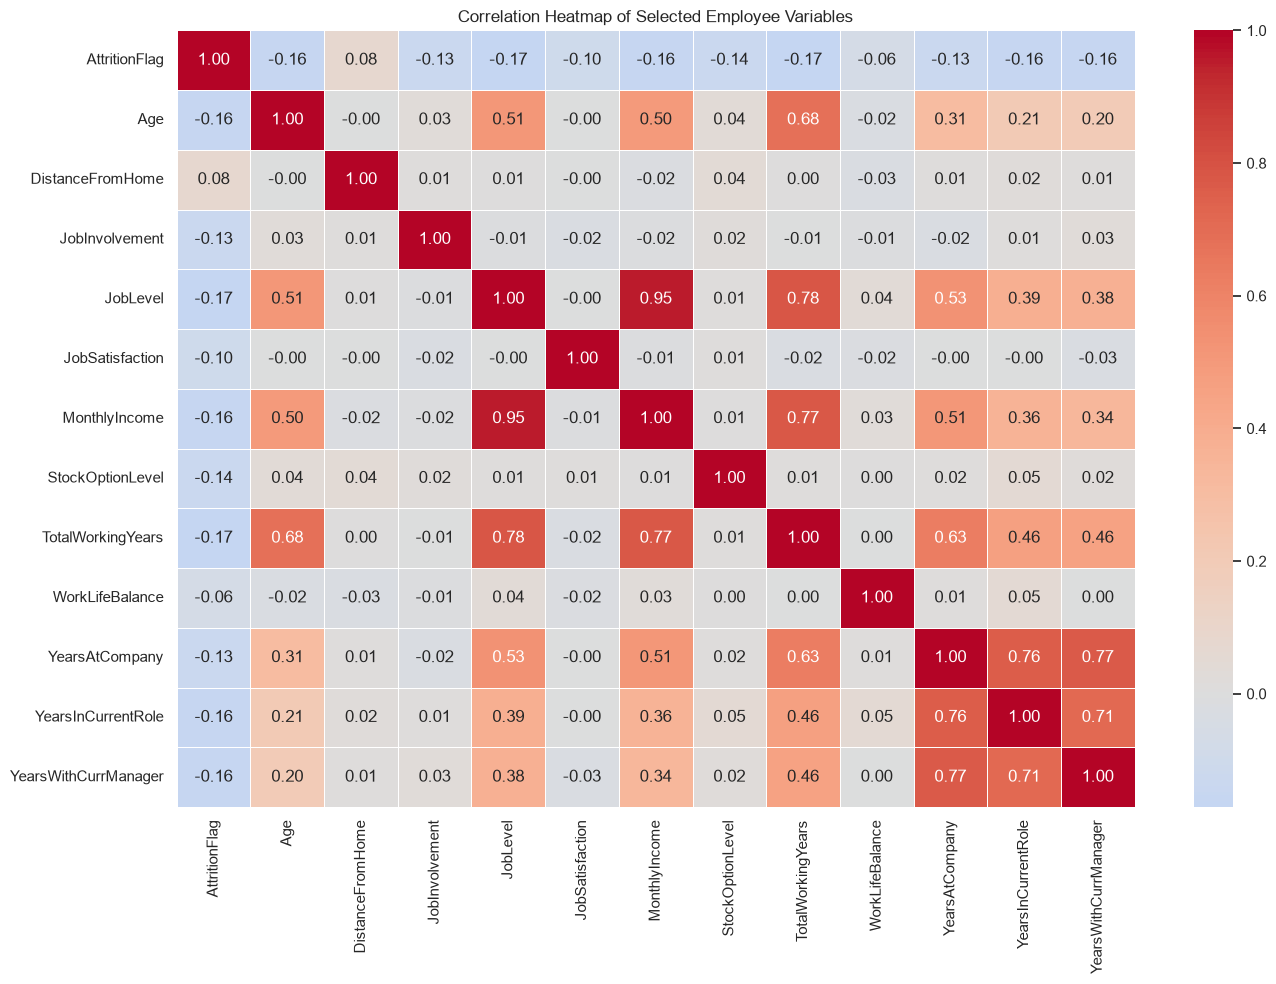

In [20]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Selected Employee Variables")
plt.tight_layout()
plt.show()

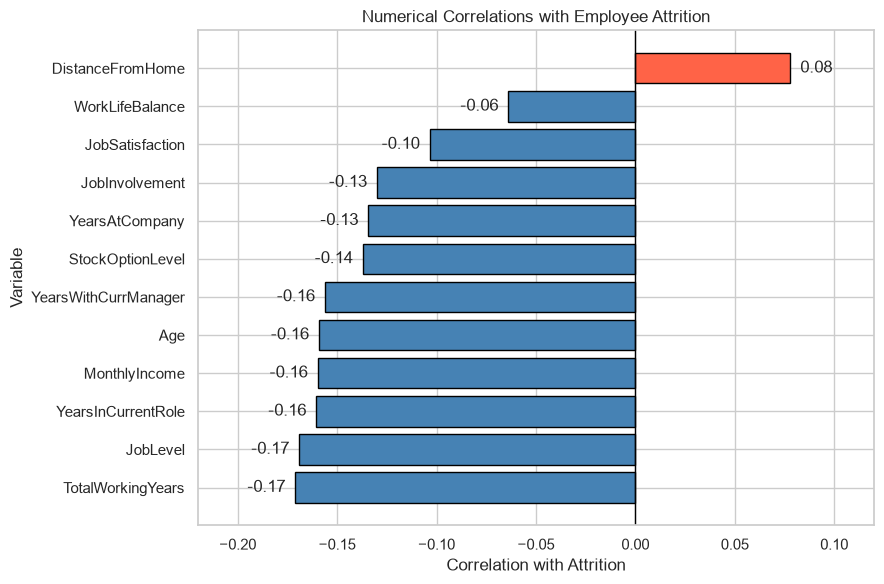

In [21]:
attrition_correlations = (
    correlation_matrix["AttritionFlag"]
    .drop("AttritionFlag")
    .sort_values()
)

plt.figure(figsize=(9, 6))

colors = [
    "steelblue" if value < 0 else "tomato"
    for value in attrition_correlations
]

bars = plt.barh(
    attrition_correlations.index,
    attrition_correlations.values,
    color=colors,
    edgecolor="black"
)

plt.title("Numerical Correlations with Employee Attrition")
plt.xlabel("Correlation with Attrition")
plt.ylabel("Variable")
plt.axvline(0, color="black", linewidth=1)

for bar, value in zip(bars, attrition_correlations.values):
    position = value - 0.005 if value < 0 else value + 0.005
    alignment = "right" if value < 0 else "left"

    plt.text(
        position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha=alignment
    )

plt.xlim(-0.22, 0.12)
plt.tight_layout()
plt.show()